# GNN - Feature Design

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

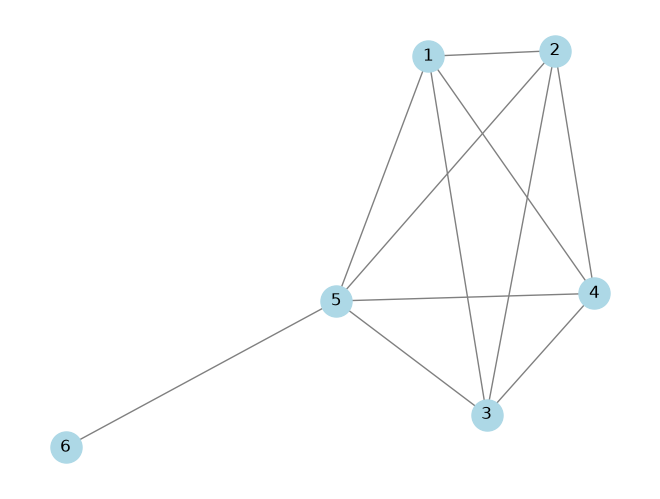

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
G = nx.Graph()

# Add nodes and edges
G.add_edges_from([(1, 2), (1, 3), (2, 4), (3, 4), (4, 5), (3, 5), (2, 5), (1, 5), (2,3),(1,4), (5,6)])

# Draw the graph
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
plt.show()

# Comprehensive Graph Analysis: Eigenvector Centrality & Power Iteration

---

## 1. Mathematical Foundation
Eigenvector centrality states that the centrality score of a node depends directly on the scores of its connected neighbors. Mathematically, this forms a classic eigenvalue problem:

$$AX = \lambda X$$

*   $A$: The $5 \times 5$ Adjacency Matrix of the graph.
*   $X$: The Eigenvector containing the **Centrality Scores** ($[S_1, S_2, S_3, S_4, S_5]^T$).
*   $\lambda$: The Eigenvalue acting as a constant scaling factor.

---

## 2. Matrix Representation & Structural Equations

### The Adjacency Matrix ($A$)
```text
       1  2  3  4  5
1 -> [[0  1  1  0  0]
2 ->  [1  0  0  1  0]
3 ->  [1  0  0  1  0]
4 ->  [0  1  1  0  1]
5 ->  [0  0  0  1  0]]
```

### The Linear System (Row-by-Row Multiplication)
Applying the definition $Score_i = \sum_{j} A_{ij} \cdot Score_j$, we get the exact systemic equations for our 5 nodes:

*   $Score_1 = Score_2 + Score_3$
*   $Score_2 = Score_1 + Score_4$
*   $Score_3 = Score_1 + Score_4$
*   $Score_4 = Score_2 + Score_3 + Score_5$
*   $Score_5 = Score_4$

$$A \cdot Score = \lambda \cdot Score$$

---

## 3. The Iterative Process (Power Iteration Method)
Instead of executing computationally heavy matrix factorization, we can solve this dynamically by running an iterative feedback loop. 

### Step 1: Initialization ($t = 0$)
We start by assigning a uniform baseline score of `1` to every single node in the network:
$$Score^{(0)} = \begin{bmatrix} 1 \\ 1 \\ 1 \\ 1 \\ 1 \end{bmatrix}$$

### Step 2: First Iteration ($t = 1$)
We pass our initial values ($Score^{(0)}$) directly through our structural equations:
*   $S_1^{(1)} = 1 + 1 = 2$
*   $S_2^{(1)} = 1 + 1 = 2$
*   $S_3^{(1)} = 1 + 1 = 2$
*   $S_4^{(1)} = 1 + 1 + 1 = 3$
*   $S_5^{(1)} = 1$

$$Score^{(1)} = \begin{bmatrix} 2 \\ 2 \\ 2 \\ 3 \\ 1 \end{bmatrix}$$

### Step 3: Second Iteration ($t = 2$)
Now, we feed the updated vector $Score^{(1)}$ back into the exact same equations:
*   $S_1^{(2)} = 2 + 2 = 4$
*   $S_2^{(2)} = 2 + 3 = 5$
*   $S_3^{(2)} = 2 + 3 = 5$
*   $S_4^{(2)} = 2 + 2 + 1 = 5$
*   $S_5^{(2)} = 3$

$$Score^{(2)} = \begin{bmatrix} 4 \\ 5 \\ 5 \\ 5 \\ 3 \end{bmatrix}$$

---

## 4. Normalization & Convergence
To stop the numbers from blowing up toward infinity, we divide the vector by its total magnitude (e.g., L2 Normalization) at the end of every single step. 

$$X^{(t+1)} = \frac{AX^{(t)}}{\|AX^{(t)}\|}$$

As $t \to \infty$, the relative distribution shifts smaller and smaller until it completely stabilizes. The final converged vector perfectly yields the exact principal eigenvector output generated by NumPy!

In [3]:
A = A = nx.to_numpy_array(G)
eigenvalues_A, eigenvectors_A = np.linalg.eig(A)

print("Adjacency Eigenvectors:\n", eigenvalues_A)

Adjacency Eigenvectors:
 [ 4.05137424+0.j  0.48269595+0.j -1.5340702 +0.j -1.        +0.j
 -1.        +0.j -1.        +0.j]


In [4]:
# Find the index of the maximum eigenvalue
max_lambda_idx = np.argmax(eigenvalues_A)

# Extract the corresponding eigenvector column
max_eigenvector = eigenvectors_A[:, max_lambda_idx]

# Reshape it to a 5x1 column matrix
max_eigenvector_column = max_eigenvector.reshape(-1, 1)

print(f"Maximum Lambda (λ): {eigenvalues_A[max_lambda_idx]}")
print("Corresponding 5x1 Eigenvector:\n", max_eigenvector_column)

Maximum Lambda (λ): (4.051374241731034+0j)
Corresponding 5x1 Eigenvector:
 [[-0.43968328+0.j]
 [-0.43968328+0.j]
 [-0.43968328+0.j]
 [-0.43968328+0.j]
 [-0.46227167+0.j]
 [-0.11410244+0.j]]


In [5]:
clean_features = np.abs(max_eigenvector_column)
print(clean_features)

[[0.43968328]
 [0.43968328]
 [0.43968328]
 [0.43968328]
 [0.46227167]
 [0.11410244]]


In [6]:
# Convert the network graph back to a dense adjacency matrix
adjacency_matrix = nx.to_numpy_array(G, dtype=int)

print("Adjacency Matrix (5x5):\n", adjacency_matrix)

Adjacency Matrix (5x5):
 [[0 1 1 1 1 0]
 [1 0 1 1 1 0]
 [1 1 0 1 1 0]
 [1 1 1 0 1 0]
 [1 1 1 1 0 1]
 [0 0 0 0 1 0]]


## Clustering Coefficient

The **clustering coefficient** measures how much nodes in a graph tend to cluster together — it quantifies the degree to which the neighbors of a node are also connected to each other.

### Local Clustering Coefficient

For a node $v$ with $k$ neighbors, it is the fraction of pairs of neighbors that are also connected:

$$C(v) = \frac{2 \times |\{e_{jk}\}|}{k(k-1)}$$

where $|\{e_{jk}\}|$ is the number of edges among the neighbors of $v$. It ranges from **0** (no neighbors connected) to **1** (neighbors form a complete clique).

### Global Clustering Coefficient

The average local clustering coefficient over all nodes:

$$C = \frac{1}{n} \sum_{v} C(v)$$

### Key Intuition

- **High C(v)**: node is embedded in a tight, well-connected community
- **Low C(v)**: node acts as a **bridge** between communities (structural hole / broker)
- In social networks, friends of friends are often friends → real-world networks tend to have high clustering coefficients
   
- ### Relationship to Graphlets
  - The clustering coefficient is a special case of graphlet counting — it measures the ratio of **closed triangles** (3-cliques) to **open wedges** (paths of length 2) around a node. Graphlets generalize this to all small subgraph patterns.

Local Clustering Coefficients:
  Node 1: 1.0000
  Node 2: 1.0000
  Node 3: 1.0000
  Node 4: 1.0000
  Node 5: 0.6000
  Node 6: 0.0000

Global (Average) Clustering Coefficient: 0.7667
Transitivity (ratio of triangles to triads): 0.8824


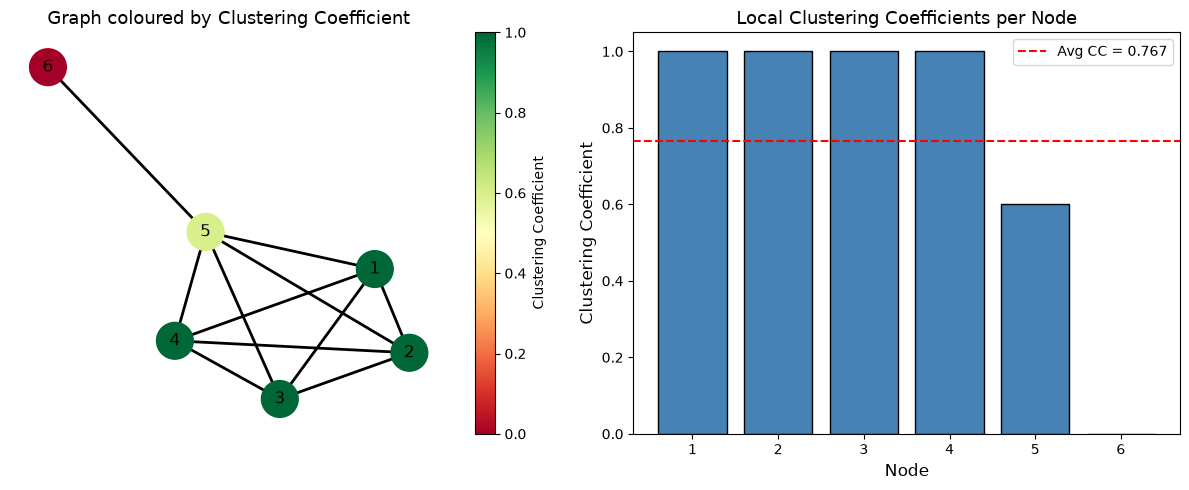

In [7]:
# 1. Local Clustering Coefficient (per node)
local_cc = nx.clustering(G)
print("Local Clustering Coefficients:")
for node, cc in local_cc.items():
    print(f"  Node {node}: {cc:.4f}")

# 2. Global (Average) Clustering Coefficient
avg_cc = nx.average_clustering(G)
print(f"\nGlobal (Average) Clustering Coefficient: {avg_cc:.4f}")

# 3. Transitivity
transitivity = nx.transitivity(G)
print(f"Transitivity (ratio of triangles to triads): {transitivity:.4f}")

# 4. Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pos = nx.spring_layout(G, seed=42)
cc_values = list(local_cc.values())
nodes_draw = nx.draw_networkx_nodes(G, pos, node_color=cc_values,
                                    cmap=plt.cm.RdYlGn, node_size=700, ax=axes[0])
nx.draw_networkx_edges(G, pos, ax=axes[0], width=2)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_color='black', font_size=12)
plt.colorbar(nodes_draw, ax=axes[0], label='Clustering Coefficient')
axes[0].set_title("Graph coloured by Clustering Coefficient", fontsize=13)
axes[0].axis('off')
axes[1].bar(local_cc.keys(), local_cc.values(), color='steelblue', edgecolor='black')
axes[1].axhline(avg_cc, color='red', linestyle='--', label=f'Avg CC = {avg_cc:.3f}')
axes[1].set_xlabel("Node", fontsize=12)
axes[1].set_ylabel("Clustering Coefficient", fontsize=12)
axes[1].set_title("Local Clustering Coefficients per Node", fontsize=13)
axes[1].legend()
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Link Level Features
- Also k/a Edge Level Features
- Describes the relationship between pair of nodes rather than a single node or whole graph
- Used for link prediction task -> Predicting whether an edge should exist b/w 2 nodes that aren't currently connected.

### Why ? 
- In many real-world problems you want to predict missing or future connections: friend recommendations in social networks, drug-target interactions, knowledge graph completion, citation prediction, etc.
- Link-level features capture the structural and relational "closeness" between two nodes.

### Categories of Link Level Features
- Distance Based Feature:
  - how far apart are the two nodes ?
  - Short distance → higher chance of a link existing
  - But it doesn't capture the degree of neighbourhood overlap.
- Local Neighbourhood Overlap: Capture neighbouring nodes shared b/w 2 nodes u and v.
  - Common Neighbors: |N(u) ∩ N(v)| — raw count of shared neighbors. More common neighbors → higher likelihood of a link.
  - Jaccard Coefficient: |N(u) ∩ N(v)| / |N(u) ∪ N(v)| ->  normalizes by total neighbors to avoid bias toward high-degree nodes.
  - Adamic-Adar Index: Σ 1/log(|N(w)|) for each common neighbor w — gives more weight to rare shared neighbors (a shared neighbor with very few connections is a stronger signal than a hub connected to everyone).
- Global Neighbourhood Overlap: Limit of local neighbourhood => |N(u) ∩ N(v)| = 0 while
  -  <img src="./graph1.png" width="300">
  - Katz Index: Count the no of the paths of all length b/w a given pair of nodes (DFS).



In [8]:
pos_edges = list(G.edges())
non_edges = list(nx.non_edges(G))
neg_edges = non_edges[:len(pos_edges)]
print("Negative Edges", "\n", "==" * 10)
print(neg_edges, "\n", "==" * 10)

Negative Edges 
[(1, 6), (2, 6), (3, 6), (4, 6)] 


## ✍︎ Practice Concepts Section

# Assignment: Node & Link Prediction on Cora using Structural Graph Features

**Dataset:** Cora citation network — 2,708 papers (nodes), 5,429 citation edges, 7 paper categories.

**Files needed:**
- `cora.content` — node features + labels (`paper_id <1433 binary word features> label`)
- `cora.cites` — edge list (`cited_paper_id  citing_paper_id`)

Download from:
```
https://raw.githubusercontent.com/tkipf/pygcn/master/data/cora/cora.content
https://raw.githubusercontent.com/tkipf/pygcn/master/data/cora/cora.cites
```

**Goal:** practice computing classic graph features (degree, clustering coefficient, eigenvector centrality, betweenness, neighborhood overlap) by hand using NetworkX, and use them — *without* any GNN — as inputs to plain sklearn classifiers.

## Setup

In [96]:
from torch_geometric.datasets import Planetoid
dataset = Planetoid(root='/tmp/Cora', name='Cora')

In [97]:
data = dataset[0]

print("=== Dataset Info ===")
print(f"Nodes:            {data.num_nodes}")
print(f"Edges:            {data.num_edges}")
print(f"Classes:          {dataset.num_classes}")
print(f"Node feature dim: {data.num_node_features}")

print("\n=== Node Feature Matrix (x) ===")
print(f"Shape: {data.x.shape}  → (num_nodes, num_word_features)")
print(f"Dtype: {data.x.dtype}")
print(f"Sample — first node, first 20 dims:\n{data.x[0, :20]}")
print(f"Words per node  min/max/mean: "
      f"{data.x.sum(dim=1).min().item():.0f} / "
      f"{data.x.sum(dim=1).max().item():.0f} / "
      f"{data.x.sum(dim=1).float().mean().item():.1f}")

print("\n=== Labels (y) ===")
print(f"Shape: {data.y.shape}")
print(f"Unique classes: {data.y.unique().tolist()}")

print("\n=== Train / Val / Test split ===")
print(f"Train: {data.train_mask.sum().item()} nodes")
print(f"Val:   {data.val_mask.sum().item()} nodes")
print(f"Test:  {data.test_mask.sum().item()} nodes")

=== Dataset Info ===
Nodes:            2708
Edges:            10556
Classes:          7
Node feature dim: 1433

=== Node Feature Matrix (x) ===
Shape: torch.Size([2708, 1433])  → (num_nodes, num_word_features)
Dtype: torch.float32
Sample — first node, first 20 dims:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1.])
Words per node  min/max/mean: 1 / 30 / 18.2

=== Labels (y) ===
Shape: torch.Size([2708])
Unique classes: [0, 1, 2, 3, 4, 5, 6]

=== Train / Val / Test split ===
Train: 140 nodes
Val:   500 nodes
Test:  1000 nodes


In [98]:
import pandas as pd

# Cora's 7 class names (fixed ordering in the dataset)
class_names = [
    "Theory",
    "Reinforcement_Learning",
    "Genetic_Algorithms",
    "Neural_Networks",
    "Probabilistic_Methods",
    "Case_Based",
    "Rule_Learning",
]

counts = {class_names[i]: (data.y == i).sum().item() for i in range(dataset.num_classes)}
df = pd.DataFrame(counts.items(), columns=["Class", "Node Count"])
df.index.name = "Label ID"
print(df.to_string())

                           Class  Node Count
Label ID                                    
0                         Theory         351
1         Reinforcement_Learning         217
2             Genetic_Algorithms         418
3                Neural_Networks         818
4          Probabilistic_Methods         426
5                     Case_Based         298
6                  Rule_Learning         180


## Cora Dataset Structure

```
                        CORA GRAPH
        ┌─────────────────────────────────────────┐
        │                                         │
        │   Node (Paper)          Edge            │
        │   ┌──────────────┐      (citation)      │
        │   │ ID: 0..2707  │◄────────────────►    │
        │   │              │                      │
        │   │ x (features) │   2,708 nodes        │
        │   │ [0,1,0,1,..] │   5,429 edges        │
        │   │  1433 dims   │   7 classes          │
        │   │              │                      │
        │   │ y (label)    │                      │
        │   │   0..6       │                      │
        │   └──────────────┘                      │
        └─────────────────────────────────────────┘

  x  →  Bag-of-words: is word_i present in this paper? (binary 0/1)
  y  →  Research topic: Theory | RL | GA | NN | PM | Case-Based | Rules
```

In [99]:
# The dataset contains 1 graph, so we access it at index 0
from torch_geometric.utils import to_networkx

G = to_networkx(dataset[0], to_undirected=False)

#plt.figure(figsize=(12, 12))


In [100]:
components = list(nx.weakly_connected_components(G))
print("Number of connected components:", len(components))
print("Sizes:", sorted([len(c) for c in components], reverse=True))

Number of connected components: 78
Sizes: [2485, 26, 9, 8, 6, 5, 5, 5, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [101]:
largest = max(nx.weakly_connected_components(G), key=len)
G_main = G.subgraph(largest).copy()
print("Nodes in main component:", G_main.number_of_nodes())
print("Edges in main component:", G_main.number_of_edges())


Nodes in main component: 2485
Edges in main component: 10138


In [102]:
degrees = [d for _, d in G_main.degree()]
print("Min degree:", min(degrees))
print("Max degree:", max(degrees))
print("Avg degree:", round(sum(degrees) / len(degrees), 2))

in_degrees = [d for _, d in G_main.in_degree()]
out_degrees = [d for _, d in G_main.out_degree()]

print("In-degree  — min:", min(in_degrees), "max:", max(in_degrees), "avg:", round(sum(in_degrees)/len(in_degrees), 2))
print("Out-degree — min:", min(out_degrees), "max:", max(out_degrees), "avg:", round(sum(out_degrees)/len(out_degrees), 2))
#In-degree = how many times a paper was cited by others (popularity)
#Out-degree = how many papers a paper cites (influence)

Min degree: 2
Max degree: 336
Avg degree: 8.16
In-degree  — min: 1 max: 168 avg: 4.08
Out-degree — min: 1 max: 168 avg: 4.08


In [103]:
import numpy as np

# get labels only for nodes in the main component
node_ids = list(G_main.nodes())
labels = data.y[node_ids].numpy()

unique, counts = np.unique(labels, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"{class_names[cls]:<25} {cnt} nodes")


Theory                    344 nodes
Reinforcement_Learning    214 nodes
Genetic_Algorithms        406 nodes
Neural_Networks           726 nodes
Probabilistic_Methods     379 nodes
Case_Based                285 nodes
Rule_Learning             131 nodes


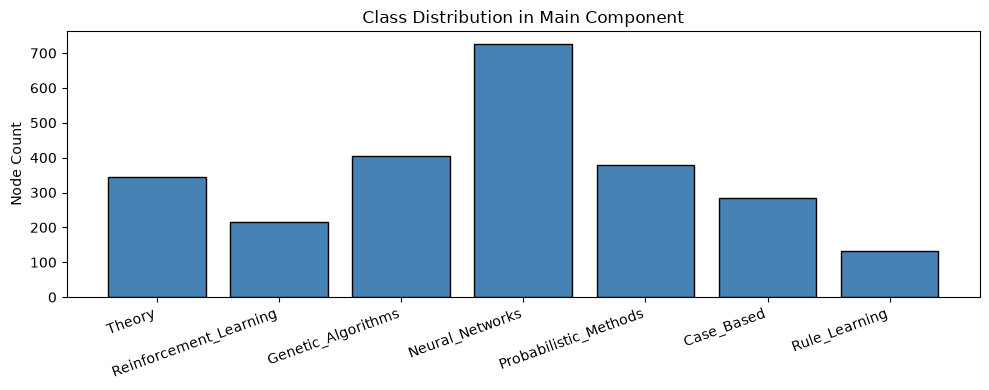

In [104]:
plt.figure(figsize=(10, 4))
plt.bar(class_names, counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=20, ha='right')
plt.ylabel("Node Count")
plt.title("Class Distribution in Main Component")
plt.tight_layout()
plt.show()


In [105]:
self_loops = list(nx.selfloop_edges(G_main))
print("Self loops:", len(self_loops))


Self loops: 0


---
## Assignment 1 — Node Classification

**Task:** Predict each paper's category (one of 7 classes) using **only graph-structural features** — do not use the word-content features for the main task.

**Steps:**

1. Compute the following node-level features for every node in `G`:
   - Degree centrality — `nx.degree(G)`
   - Clustering coefficient — `nx.clustering(G)`
   - Eigenvector centrality — `nx.eigenvector_centrality(G, max_iter=1000)`
   - Betweenness centrality (sampled for speed) — `nx.betweenness_centrality(G, k=300, seed=42)`
2. Assemble these into a feature matrix `X_struct` of shape `(2708, 4)`.
3. Encode the labels (`LabelEncoder`).
4. Train a classifier (`RandomForestClassifier` or `LogisticRegression`) using `cross_val_score` with `cv=5`.
5. Report the mean cross-validated accuracy.

In [110]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.sparse.linalg import eigs
from scipy.sparse import csr_matrix
import numpy as np

# Eigenvector centrality via exact eigendecomposition (no iteration limit)
A_sparse = csr_matrix(nx.to_scipy_sparse_array(G_main))
eigenvalue, eigenvector = eigs(A_sparse, k=1, which='LM')

eig_scores = np.abs(eigenvector.real.flatten())
eig_scores = eig_scores / eig_scores.max()  # normalize to [0, 1]
eig = dict(zip(G_main.nodes(), eig_scores))

print(f"Max eigenvalue (λ₁): {eigenvalue[0].real:.4f}")
print("Sample:", list(eig.items())[:3])

# Clustering coefficient
clus = nx.clustering(G_main.to_undirected())
print("Sample:", list(clus.items())[:3])

node_ids = list(G_main.nodes())

X_struct = np.array([
    [eig[n], clus[n]]
    for n in node_ids
])

print("X_struct shape:", X_struct.shape)

y = data.y[node_ids].numpy()
print("y shape:", y.shape)
print("Sample labels:", y[:5])

Max eigenvalue (λ₁): 14.3909
Sample: [(0, np.float64(0.00013640551370811333)), (1, np.float64(0.00014404352483835458)), (2, np.float64(0.002050447311923916))]
Sample: [(0, 0.3333333333333333), (1, 0), (2, 0)]
X_struct shape: (2485, 2)
y shape: (2485,)
Sample labels: [3 4 4 3 2]


X_combo shape: (2485, 1435)
Train: (1491, 1435) Test: (994, 1435)


/var/folders/q3/f57zrpns1x3c8zs_5y5jvgvr0000gn/T/ipykernel_21443/1645705934.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(class_names, rotation=20, ha='right')
/var/folders/q3/f57zrpns1x3c8zs_5y5jvgvr0000gn/T/ipykernel_21443/1645705934.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(class_names, rotation=20, ha='right')


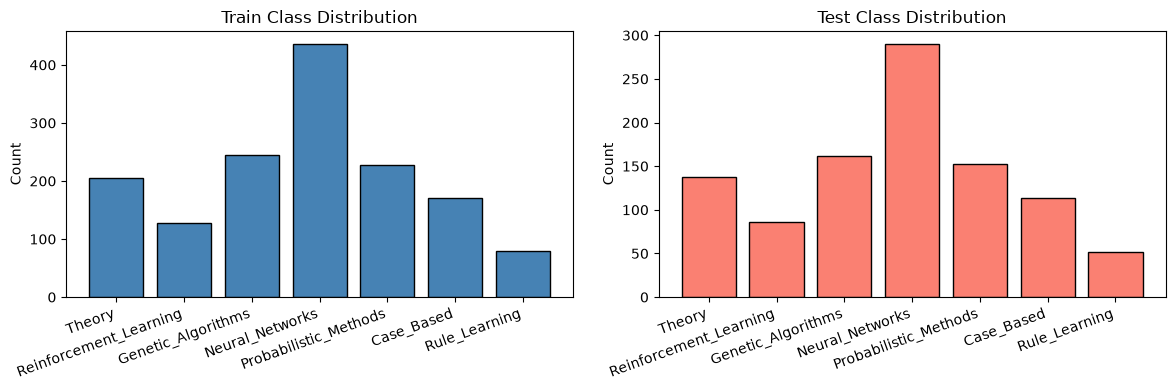

In [111]:
from sklearn.model_selection import train_test_split

X_word = data.x[node_ids].numpy()
X_combo = np.hstack([X_struct, X_word])
print("X_combo shape:", X_combo.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_combo, y, test_size=0.4, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

from collections import Counter

train_dist = Counter(y_train)
test_dist = Counter(y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_counts = [Counter(y_train)[i] for i in range(7)]
test_counts = [Counter(y_test)[i] for i in range(7)]

axes[0].bar(class_names, train_counts, color='steelblue', edgecolor='black')
axes[0].set_title("Train Class Distribution")
axes[0].set_xticklabels(class_names, rotation=20, ha='right')
axes[0].set_ylabel("Count")

axes[1].bar(class_names, test_counts, color='salmon', edgecolor='black')
axes[1].set_title("Test Class Distribution")
axes[1].set_xticklabels(class_names, rotation=20, ha='right')
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [112]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Classifier
clf = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)

# Stratified CV on train set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='balanced_accuracy')
print("CV scores:", scores.round(3))
print("CV mean:  ", scores.mean().round(3))

# Fit and evaluate on test set
clf.fit(X_train, y_train)
test_acc = clf.score(X_test, y_test)
print("Test accuracy:", round(test_acc, 3))


CV scores: [0.711 0.76  0.704 0.68  0.722]
CV mean:   0.716
Test accuracy: 0.752


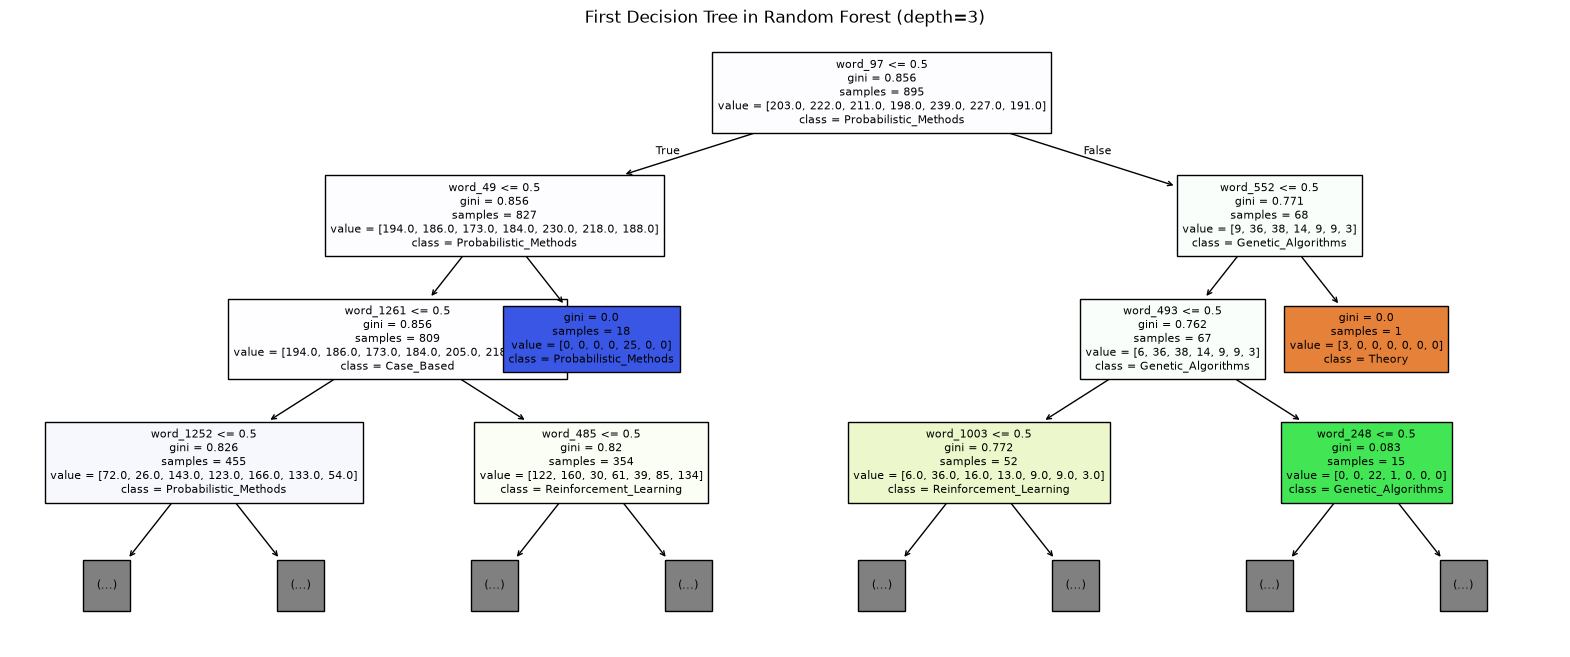

In [113]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    clf.estimators_[0],  # first tree in the forest
    max_depth=3,         # only show top 3 levels
    filled=True,
    feature_names=['degree', 'clustering', 'eigenvector', 'betweenness'] + [f'word_{i}' for i in range(1433)],
    class_names=class_names,
    fontsize=8
)
plt.title("First Decision Tree in Random Forest (depth=3)")
plt.show()

### Bonus
- Repeat using only `word_features` (1433-dim bag-of-words). Compare accuracy.
- Repeat using `word_features` **stacked with** `X_struct` (`np.hstack`). Did structural features add anything on top of content?
- Which single structural feature, used alone, is the most predictive? (train 4 separate single-feature models and compare)

---
## Assignment 2 — Link Prediction

**Task:** Hide 20% of the real citation edges. Using only the remaining 80% of the graph, predict which hidden pairs of papers are actually connected — using neighborhood-overlap features, not the labels at all.

**Steps:**

1. Shuffle the edge list and split it: 80% `train_edges`, 20% `hidden_edges` (positive test examples).
2. Build `G_train` using only `train_edges`.
3. Sample an equal number of **negative** examples: random pairs `(u, v)` not connected anywhere in the *full* original graph.
4. For every candidate pair `(u, v)`, compute these features **using only `G_train`**:
   - Common neighbors
   - Jaccard similarity
   - Preferential attachment score (`deg(u) * deg(v)`)
   - Degree sum
5. Split into train/test and train a classifier to predict edge-exists (1) vs not (0).
6. Report Accuracy, AUC-ROC, and `clf.feature_importances_`.

In [114]:
import random

random.seed(42)

pos_edges = list(G_main.edges())
all_non_edges = list(nx.non_edges(G_main))
neg_edges = random.sample(all_non_edges, len(pos_edges))

print("Positive edges:", len(pos_edges))
print("Negative edges:", len(neg_edges))


Positive edges: 10138
Negative edges: 10138


In [115]:
G_undirected = G_main.to_undirected()

# Common Neighbors
cn = {(u, v): len(list(nx.common_neighbors(G_undirected, u, v))) 
      for u, v in pos_edges + neg_edges}

# Jaccard Coefficient
jc = {(u, v): p 
      for u, v, p in nx.jaccard_coefficient(G_undirected, pos_edges + neg_edges)}

# Adamic-Adar
aa = {(u, v): p 
      for u, v, p in nx.adamic_adar_index(G_undirected, pos_edges + neg_edges)}

print("Sample CN:", list(cn.items())[:3])
print("Sample JC:", list(jc.items())[:3])
print("Sample AA:", list(aa.items())[:3])


Sample CN: [((0, 633), 0), ((0, 1862), 1), ((0, 2582), 1)]
Sample JC: [((0, 633), 0.0), ((0, 1862), 0.16666666666666666), ((0, 2582), 0.2)]
Sample AA: [((0, 633), 0), ((0, 1862), 0.9102392266268373), ((0, 2582), 0.7213475204444817)]


In [116]:
import numpy as np

all_edges = pos_edges + neg_edges
labels = [1] * len(pos_edges) + [0] * len(neg_edges)

X_link = np.array([
    [cn[(u, v)], jc[(u, v)], aa[(u, v)]]
    for u, v in all_edges
])
y_link = np.array(labels)

print("X_link shape:", X_link.shape)
print("y_link shape:", y_link.shape)
print("Sample row:", X_link[0])


X_link shape: (20276, 3)
y_link shape: (20276,)
Sample row: [0. 0. 0.]


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from scipy.sparse.linalg import inv
from scipy.sparse import eye, csc_matrix
import networkx as nx

# --- Step 1: Split edges FIRST (before computing any features) ---
all_edges = pos_edges + neg_edges
y_link = np.array([1] * len(pos_edges) + [0] * len(neg_edges))

train_idx, test_idx = train_test_split(
    range(len(all_edges)), test_size=0.2, stratify=y_link, random_state=42
)

train_edges = [all_edges[i] for i in train_idx]
test_edges  = [all_edges[i] for i in test_idx]
y_train_l   = y_link[train_idx]
y_test_l    = y_link[test_idx]

# Positive training edges only — used to build the training graph
train_pos_edges = [all_edges[i] for i in train_idx if y_link[i] == 1]

# --- Step 2: Build training graph (no test edges!) ---
G_train = nx.DiGraph()
G_train.add_nodes_from(G_main.nodes())
G_train.add_edges_from(train_pos_edges)
G_train_und = G_train.to_undirected()

# --- Step 3: Compute Katz matrix on training graph only ---
beta = 0.01
node_list = list(G_main.nodes())
_id_map = {node: i for i, node in enumerate(node_list)}

A_train = nx.to_scipy_sparse_array(G_train_und, nodelist=node_list)
I_mat = eye(A_train.shape[0], format='csc')
katz_matrix = inv(I_mat - beta * csc_matrix(A_train)) - I_mat
print("Katz matrix computed on training graph only.")

# --- Step 4: Compute all features on training graph ---
def get_features(edges, G_und, katz_matrix, _id_map, eig, clus):
    cn = {(u, v): len(list(nx.common_neighbors(G_und, u, v))) for u, v in edges}
    jc = {(u, v): p for u, v, p in nx.jaccard_coefficient(G_und, edges)}
    aa = {(u, v): p for u, v, p in nx.adamic_adar_index(G_und, edges)}
    X = np.array([
        [cn[(u,v)], jc[(u,v)], aa[(u,v)],
         katz_matrix[_id_map[u], _id_map[v]],
         eig[u], clus[u], eig[v], clus[v]]
        for u, v in edges
    ])
    return X

X_train_l = get_features(train_edges, G_train_und, katz_matrix, _id_map, eig, clus)
X_test_l  = get_features(test_edges,  G_train_und, katz_matrix, _id_map, eig, clus)

print("Train shape:", X_train_l.shape, "| Test shape:", X_test_l.shape)

# --- Step 5: Train and evaluate ---
clf_link = RandomForestClassifier(n_estimators=16, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf_link, X_train_l, y_train_l, cv=cv, scoring='roc_auc')
print("CV AUC scores:", scores.round(3))
print("CV AUC mean:  ", scores.mean().round(3))

clf_link.fit(X_train_l, y_train_l)
y_pred_proba = clf_link.predict_proba(X_test_l)[:, 1]
print("Test AUC:     ", round(roc_auc_score(y_test_l, y_pred_proba), 3))
print("Test accuracy:", round(clf_link.score(X_test_l, y_test_l), 3))

# --- Feature importance ---
feature_names = ['common_neighbors', 'jaccard', 'adamic_adar', 'katz', 'eig_u', 'clus_u', 'eig_v', 'clus_v']
for name, imp in zip(feature_names, clf_link.feature_importances_):
    print(f"{name:<20} {imp:.3f}")

In [126]:
threshold = np.percentile(eig_vals, 95)  # top 5%
top_nodes = [(node_list[i], eig_vals[i]) for i in range(len(node_list)) if eig_vals[i] >= threshold]
top_nodes_sorted = sorted(top_nodes, key=lambda x: x[1], reverse=True)

print(f"Threshold (95th percentile): {threshold:.4f}")
print(f"Number of top nodes: {len(top_nodes_sorted)}")
print("\nTop 10 nodes:")
for node, score in top_nodes_sorted[:10]:
    print(f"  Node {node:<5} | eig: {score:.4f} | class: {class_names[data.y[node].item()]}")


Threshold (95th percentile): 0.0766
Number of top nodes: 125

Top 10 nodes:
  Node 1358  | eig: 1.0000 | class: Genetic_Algorithms
  Node 1169  | eig: 0.1802 | class: Genetic_Algorithms
  Node 1765  | eig: 0.1517 | class: Genetic_Algorithms
  Node 1725  | eig: 0.1404 | class: Genetic_Algorithms
  Node 1072  | eig: 0.1395 | class: Genetic_Algorithms
  Node 1103  | eig: 0.1380 | class: Genetic_Algorithms
  Node 1483  | eig: 0.1331 | class: Genetic_Algorithms
  Node 154   | eig: 0.1306 | class: Genetic_Algorithms
  Node 748   | eig: 0.1177 | class: Genetic_Algorithms
  Node 687   | eig: 0.1143 | class: Genetic_Algorithms


In [127]:
from collections import Counter

top_classes = [class_names[data.y[node].item()] for node, _ in top_nodes_sorted]
class_counts = Counter(top_classes)

for cls, cnt in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{cls:<25} {cnt} nodes")


Genetic_Algorithms        119 nodes
Reinforcement_Learning    4 nodes
Theory                    1 nodes
Neural_Networks           1 nodes


In [130]:
# Pick node 1358 (highest eig) and show its neighbours
node = 1358
in_neighbors = list(G_main.predecessors(node))
out_neighbors = list(G_main.successors(node))

print(f"Node {node} | eig: {eig[node]:.4f} | class: {class_names[data.y[node].item()]}")
print(f"Cited by (in-degree):  {len(in_neighbors)} papers")
print(f"Cites (out-degree):    {len(out_neighbors)} papers")
print(f"\nTop 5 papers that cite node {node}:")
for n in in_neighbors[:5]:
    print(f"  Node {n:<5} | eig: {eig[n]:.4f} | class: {class_names[data.y[n].item()]}")


Node 1358 | eig: 1.0000 | class: Genetic_Algorithms
Cited by (in-degree):  168 papers
Cites (out-degree):    168 papers

Top 5 papers that cite node 1358:
  Node 30    | eig: 0.0713 | class: Neural_Networks
  Node 34    | eig: 0.0695 | class: Genetic_Algorithms
  Node 53    | eig: 0.0864 | class: Genetic_Algorithms
  Node 59    | eig: 0.1032 | class: Genetic_Algorithms
  Node 68    | eig: 0.0721 | class: Genetic_Algorithms


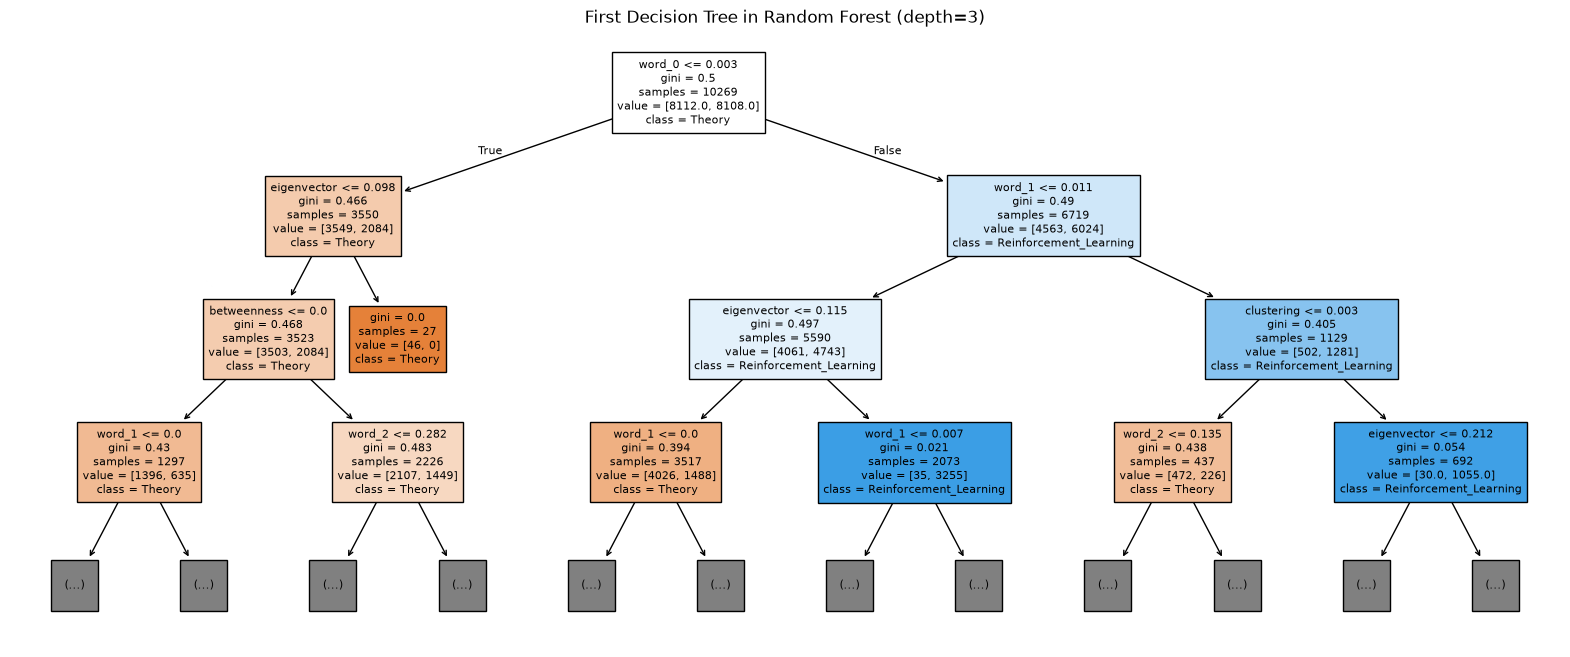

In [131]:
plt.figure(figsize=(20, 8))
plot_tree(
    clf_link.estimators_[0],  # first tree in the forest
    max_depth=3,         # only show top 3 levels
    filled=True,
    feature_names=['degree', 'clustering', 'eigenvector', 'betweenness'] + [f'word_{i}' for i in range(1433)],
    class_names=class_names,
    fontsize=8
)
plt.title("First Decision Tree in Random Forest (depth=3)")
plt.show()

In [132]:
import pandas as pd

df = pd.DataFrame({
    'eig_u': [eig[u] for u, v in all_edges],
    'eig_v': [eig[v] for u, v in all_edges],
    'label': y_link
})

# Bin eigenvector scores into high/low
threshold = np.median(df['eig_u'])
df['u_group'] = df['eig_u'].apply(lambda x: 'high' if x > threshold else 'low')
df['v_group'] = df['eig_v'].apply(lambda x: 'high' if x > threshold else 'low')
df['pair_type'] = df['u_group'] + '_' + df['v_group']

result = df.groupby('pair_type')['label'].mean()
print("Edge probability by pair type:")
print(result.round(3))


Edge probability by pair type:
pair_type
high_high    0.700
high_low     0.276
low_high     0.272
low_low      0.533
Name: label, dtype: float64


In [142]:
from scipy.sparse.linalg import inv
from scipy.sparse import eye, csc_matrix

# beta must be < 1/max_eigenvalue (1/14.39 = 0.069), use 0.01 to be safe
beta = 0.01
A = nx.to_scipy_sparse_array(G_main.to_undirected())
I = eye(A.shape[0], format='csc')
katz_matrix = inv(I - beta * csc_matrix(A)) - I

print("Katz matrix shape:", katz_matrix.shape)

# Extract Katz scores for all edge pairs
katz_pos = [katz_matrix[node_id_map[u], node_id_map[v]] for u, v in pos_edges]
katz_neg = [katz_matrix[node_id_map[u], node_id_map[v]] for u, v in neg_edges]

print(f"Avg Katz score — positive edges: {np.mean(katz_pos):.4f}")
print(f"Avg Katz score — negative edges: {np.mean(katz_neg):.4f}")

Katz matrix shape: (2485, 2485)
Avg Katz score — positive edges: 0.0101
Avg Katz score — negative edges: 0.0000


## Experiments